<a href="https://colab.research.google.com/github/dmmcatee/week3-dimensionality-reduction/blob/main/Dimensionality_Reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("uciml/iris")

Using Colab cache for faster access to the 'iris' dataset.


In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (assuming 'path' is the directory where the iris dataset is located)
# The 'path' variable is from the previous step which downloaded the 'iris' dataset.
# A common structure for kaggle datasets is a subdirectory named after the dataset inside the downloaded path.
# Let's try to find the CSV file in the 'path' directory.

import os
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if csv_files:
    iris_filepath = os.path.join(path, csv_files[0])
    iris_df = pd.read_csv(iris_filepath)
else:
    print(f"No CSV file found in the directory: {path}")
    # Fallback if the above doesn't work, assuming a common filename.
    # This part might need adjustment based on the actual content of the downloaded dataset.
    try:
        iris_df = pd.read_csv(os.path.join(path, 'Iris.csv')) # Common filename for Iris dataset
    except FileNotFoundError:
        iris_df = pd.read_csv(os.path.join(path, 'iris.csv')) # Another common filename

display(iris_df.head())

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
from sklearn.manifold import TSNE
import time

# Apply t-SNE
time_start = time.time()
tsne = TSNE(n_components=2, verbose=1, perplexity=30, n_iter=300)
tsne_results = tsne.fit_transform(X_scaled)
print(f't-SNE done! Time elapsed: {time.time()-time_start} seconds')

# Create a DataFrame for the t-SNE results
tsne_df = pd.DataFrame(data = tsne_results, columns = ['tsne component 1', 'tsne component 2'])
tsne_df = pd.concat([tsne_df, y], axis = 1)

display(tsne_df.head())

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 150 samples in 0.000s...
[t-SNE] Computed neighbors for 150 samples in 0.041s...
[t-SNE] Computed conditional probabilities for sample 150 / 150
[t-SNE] Mean sigma: 0.809758
[t-SNE] KL divergence after 250 iterations with early exaggeration: 45.393078
[t-SNE] KL divergence after 300 iterations: 0.175161
t-SNE done! Time elapsed: 0.23689866065979004 seconds


,tsne component 1,tsne component 2,Species
0,-11.218015,-1.509019,Iris-setosa
1,-9.041546,1.269903,Iris-setosa
2,-9.220874,0.680840,Iris-setosa
3,-9.203276,1.271090,Iris-setosa
4,-11.247602,-1.813521,Iris-setosa


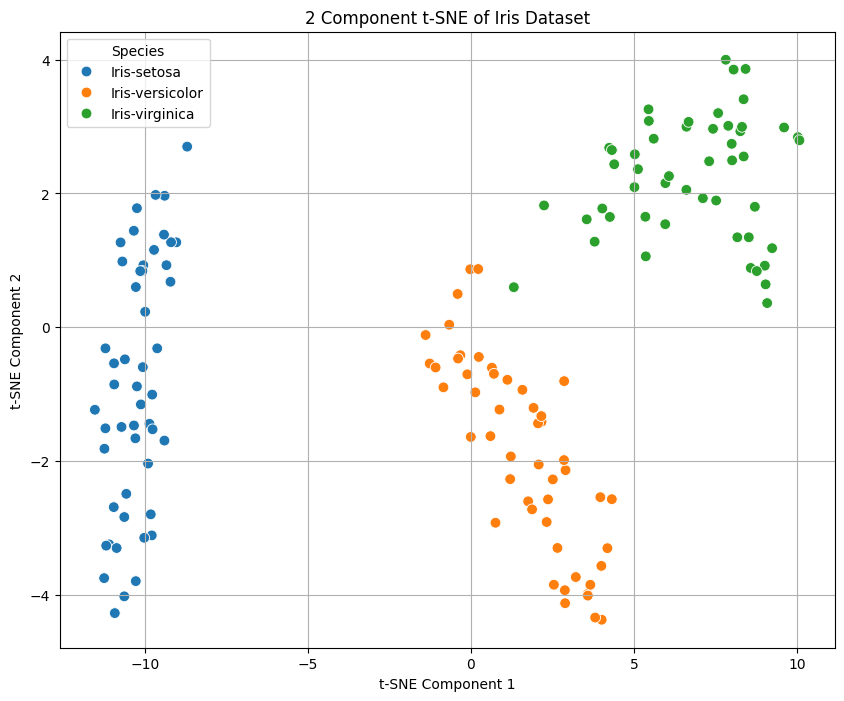

In [7]:
# Plot the 2 t-SNE components
plt.figure(figsize=(10, 8))
sns.scatterplot(x='tsne component 1', y='tsne component 2', hue='Species', data=tsne_df, s=60)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('2 Component t-SNE of Iris Dataset')
plt.grid()
plt.show()

In [3]:
# Separate features and target variable
X = iris_df.drop('Species', axis=1) # Assuming 'Species' is the target column
y = iris_df['Species']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for the PCA results
pca_df = pd.DataFrame(data = X_pca, columns = ['principal component 1', 'principal component 2'])
pca_df = pd.concat([pca_df, y], axis = 1)

display(pca_df.head())

,principal component 1,principal component 2,Species
0,-2.816339,0.506051,Iris-setosa
1,-2.645527,-0.651799,Iris-setosa
2,-2.879481,-0.321036,Iris-setosa
3,-2.810934,-0.577363,Iris-setosa
4,-2.879884,0.670468,Iris-setosa


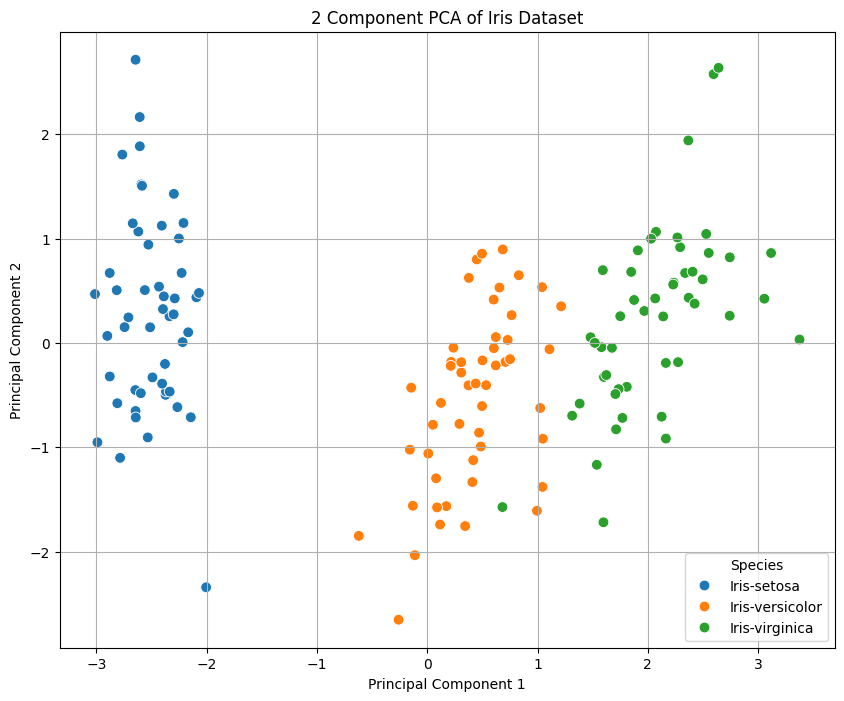

In [4]:
# Plot the 2 principal components
plt.figure(figsize=(10, 8))
sns.scatterplot(x='principal component 1', y='principal component 2', hue='Species', data=pca_df, s=60)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2 Component PCA of Iris Dataset')
plt.grid()
plt.show()

**Visually**
- PCA
  - Setosa (blue) is clearly separated. Versicolor and Virginica overlap somewhat. Clusters are separated mostly along PC1.
  - shows one very distinct cluster (Setosa0 and two partially overlapping clusters.
  - clusters are more stretched and liner, spreading mainly along principal directions.
  - if one cluster is twice as far, it really is more different
- t-SNE
  - all three species form clearly separated clusters.
  - Versicolor and Virginica separate more cleanly.
  - clusters appear more intact.
  - shows three distinct, clean groups with less overlap.
  - clutsters look rounder and tighter with more natural grouping.
  - nearby points are more meaningful.

**Numerical**
- PCA
  - PCA keeps most dataset structure
  - finds directions of maximum variance
  - linear transformation
  - good for compression

- t-SNE
  - preserves local neighborhood relationships and minimizes probability differences between neighbors
  - groups similar points together
  - nonlinear transformation
  - great for visualization